# Re-design

## Алгоритм построен по принципу направленного эволюционного дизайна координационных металлокомплексов и состоит из четырех последовательных фаз:
1. Экстракция фрагментов (Автосборка Атласа): Программа берет обучающий датасет, находит металлоцентры и виртуально разрушает связи металл-лиганд. Отсекая металл, алгоритм фильтрует чистую органику и выделяет фрагменты размером от 2 до 12 тяжелых атомов. Это гарантирует, что в «Атлас мутаций» попадут только синтетически доступные и стабильные структуры, встречающиеся в реальной медицинской химии.
2. Селективная Хемо-защита: Принимая на вход целевой комплекс, алгоритм разворачивает систему правил безопасности. Он блокирует от замещения анионные функциональные группы (Cl, Br, I, F), координированные кислороды (O) и структурные мостики (например, нитрильные группы C#N). Мутациям подвергаются исключительно периферийные лабильные органические лиганды.
3. Хирально-направленное комбинаторное ветвление:
Модификация структуры происходит на двух уровнях (одноточечные и двухточечные независимые замены). Главное отличие обновленной версии: при сборке нового комплекса RDKit принудительно рассчитывает и фиксирует пространственную конфигурацию молекулы с помощью функции AssignStereochemistry. Слэши (/, \) и хиральные спецификаторы сохраняются, что позволяет генерировать и различать геометрические изомеры (например, разделять траектории оптимизации для цис- и транс-форм).
4. Многофакторный отбор (Ранжирование по Fitness Score): Сгенерированные структуры оцениваются по формуле полезности:
Fitness=ΔpIC50−(0.04×SA Score). Алгоритм отбирает молекулы, которые одновременно максимизируют противоопухолевую активность (ΔpIC50>0) и минимизируют сложность химического синтеза (SA→1). Параллельно рассчитывается дескрипторный профиль Липинского (Ro5) для отсечения соединений с плохой мембранной проницаемостью.

## Фундаментальные ограничения алгоритма
При использовании алгоритма в реальных исследованиях необходимо учитывать следующие ограничения:
1. Координационные геометрические изомеры: Алгоритм оперирует топологическими графами (2D SMILES) и не учитывает пространственную изомерию (например, цис- и транс- планарные конфигурации, оптические изомеры октаэдрических комплексов рутения). Наличие стереоизомеров может радикально менять биологический ответ модели.
2. Фиксированная валентность металлоцентра: Генератор умеет разрывать и сшивать связи синглетного типа, но он не способен самостоятельно изменять координационное число или степень окисления металла (например, переводить Pt(II) в октаэдрическую форму Pt(IV)).
3. Качество дескрипторов Липинского (Ro5) для металлов: Математические калькуляторы липофильности (LogP) в RDKit (алгоритм Wildman-Crippen) разработаны строго для классической органики. Значения LogP для координационных комплексов с металлами рассчитываются оценочно и могут иметь погрешность, связанную с неучтенным эффектом поляризации и ионного характера связей металл-лиганд.
4. Зависимость от контекста датасета: Прогностический ИИ-модуль (CatBoost) жестко привязан к признакам исходной таблицы. Если в обучающей выборке не было определенных гетероциклов, модель предскажет их свойства с высокой дисперсией (эффект выхода за границы применимости модели / Applicability Domain).

работает с рутением, но полностью игнорирует цис и транс 

[1/3] Обучение прогностической модели CatBoost (стерео-зависимая конфигурация)...
[2/3] Автосборка Атласа фрагментов из всего доступного хим. пространства...
[INFO] В Атлас извлечено 62 контролируемых organic-фрагментов.

[3/3] Выборка тест-систем для проверки многоуровневого скрининга...

>>> КОМБИНАТОРНЫЙ ТЕСТ ГЛУБИНЫ №1 <<<

 РЕЗУЛЬТАТЫ СБАЛАНСИРОВАННОЙ МНОГОУРОВНЕВОЙ МУТАЦИИ
 Исходный SMILES : [Pt](N)(Cl)(Cl)(O)(O)CN1CCCCC1C
 Базовый pIC50   : 5.642 | Сложность структуры SA: 4.63/10
 Lipinski Ro5    : MW=428.2 | LogP=1.04 | HBD=3 | HBA=4 | TPSA=69.7
 Фильтр Lipinski : Пройдено
 Хемо-защита     : Заблокировано 5 критических позиций.
-------------------------------------------------------------------------------------
 [1] Лид-Кандидат: CC1CCCCN1[CH2][Pt]([OH])([OH])([Cl])([Cl])[O]CCNCCO
     pIC50: 5.669 (+0.027) | Сложность SA: 4.40/10
     Lipinski Ro5: MW=516.3 | LogP=0.68 | HBD=4 | HBA=6 | TPSA=85.2
     Фильтр Lipinski : Пройдено
------------------------------------------------

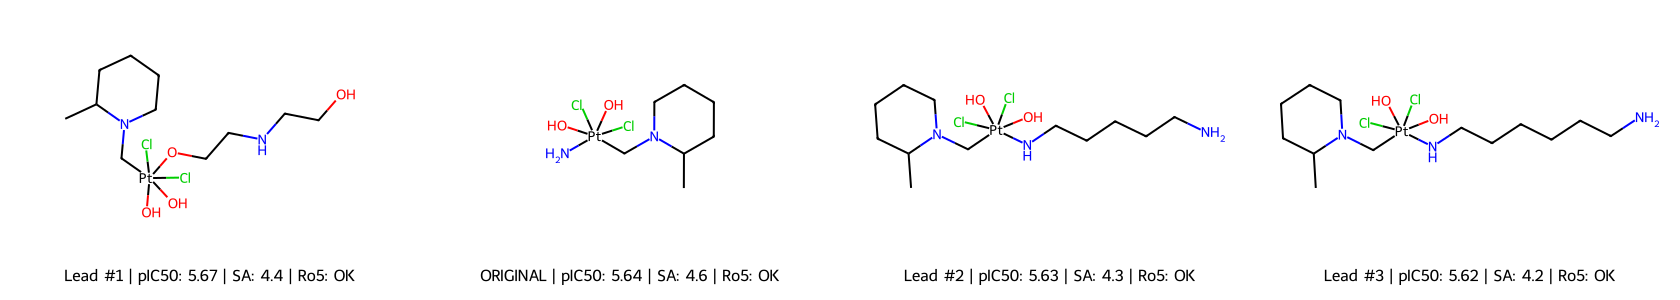


>>> КОМБИНАТОРНЫЙ ТЕСТ ГЛУБИНЫ №2 <<<

 РЕЗУЛЬТАТЫ СБАЛАНСИРОВАННОЙ МНОГОУРОВНЕВОЙ МУТАЦИИ
 Исходный SMILES : [Ru](N(N(N(Nc1cccnc1)c2cccnc2)c3cccnc3)N(N(Nc1cccnc1)c2cccnc2)c3cccnc3)(O[N+](=O)[O-])O[N+](=O)[O-]
 Базовый pIC50   : 5.015 | Сложность структуры SA: 4.23/10
 Lipinski Ro5    : MW=793.7 | LogP=4.18 | HBD=2 | HBA=19 | TPSA=222.3
 Фильтр Lipinski : Нарушено (2 наруш.)
 Хемо-защита     : Заблокировано 2 критических позиций.
-------------------------------------------------------------------------------------
 [1] Лид-Кандидат: CC(C)(C)C(C)(N)C(C)(C)[CH2][Ru]([O][N+](=O)[O-])[O][N+](=O)[O-]
     pIC50: 5.609 (+0.594) | Сложность SA: 4.91/10
     Lipinski Ro5: MW=381.4 | LogP=2.06 | HBD=1 | HBA=7 | TPSA=130.8
     Фильтр Lipinski : Пройдено
-------------------------------------------------------------------------------------
 [2] Лид-Кандидат: NCC1([CH2][Ru]([O][N+](=O)[O-])[O][N+](=O)[O-])CC2CC3CC2C1C3
     pIC50: 5.646 (+0.631) | Сложность SA: 6.30/10
     Lipinski Ro5: MW=389.4

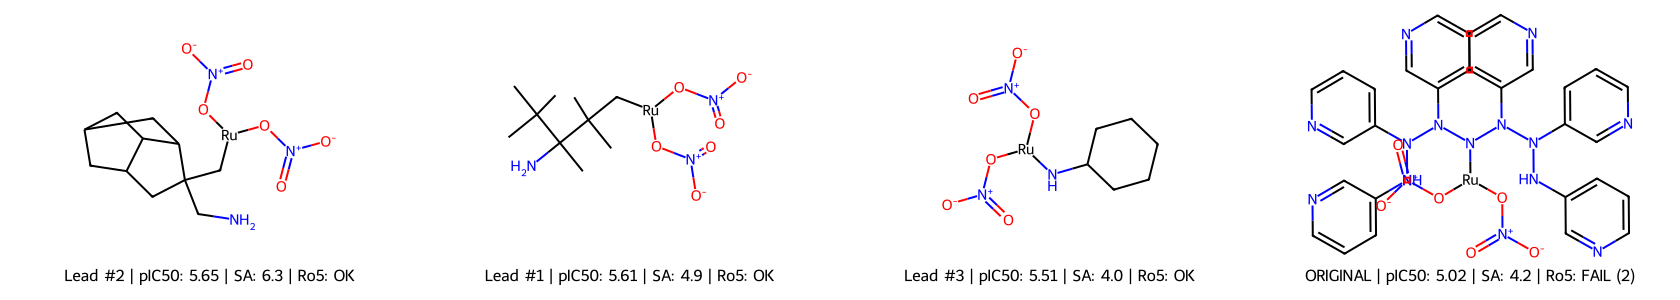


>>> КОМБИНАТОРНЫЙ ТЕСТ ГЛУБИНЫ №3 <<<

 РЕЗУЛЬТАТЫ СБАЛАНСИРОВАННОЙ МНОГОУРОВНЕВОЙ МУТАЦИИ
 Исходный SMILES : [Au](C#N)(C#N)(c1ccc(cc1)CN(C)C)
 Базовый pIC50   : 5.108 | Сложность структуры SA: 3.82/10
 Lipinski Ro5    : MW=383.2 | LogP=0.95 | HBD=0 | HBA=3 | TPSA=50.8
 Фильтр Lipinski : Пройдено
 Хемо-защита     : Заблокировано 2 критических позиций.
-------------------------------------------------------------------------------------
 [1] Лид-Кандидат: CC(C)(C)C(C)(N)C(C)(C)[CH2][Au]([C]#N)[C]#N
     pIC50: 5.678 (+0.570) | Сложность SA: 5.04/10
     Lipinski Ro5: MW=405.3 | LogP=2.77 | HBD=1 | HBA=3 | TPSA=73.6
     Фильтр Lipinski : Пройдено
-------------------------------------------------------------------------------------
 [2] Лид-Кандидат: N#[C][Au]([C]#N)[CH2]C1(CN)CC2CC3CC2C1C3
     pIC50: 5.717 (+0.609) | Сложность SA: 6.39/10
     Lipinski Ro5: MW=413.3 | LogP=2.00 | HBD=1 | HBA=3 | TPSA=73.6
     Фильтр Lipinski : Пройдено
------------------------------------------------

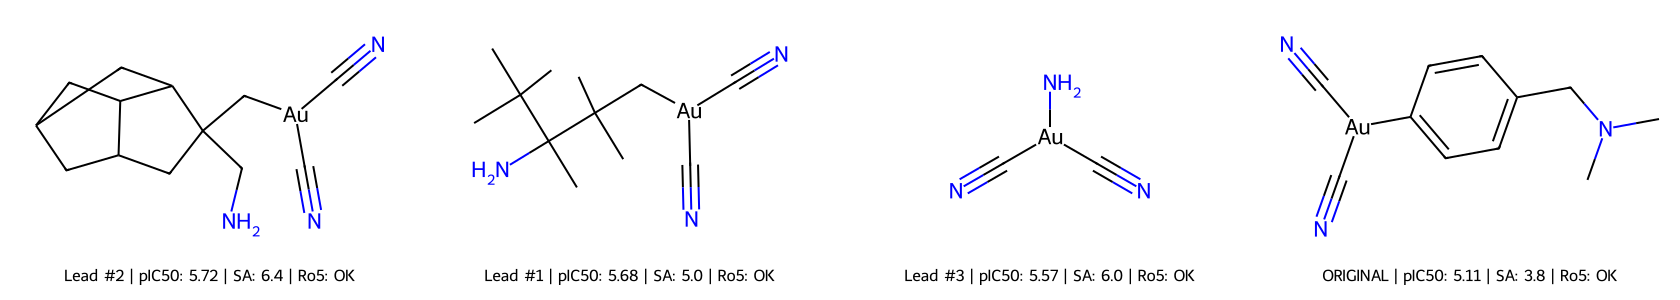

In [70]:
import os
import sys
import itertools
import random
import numpy as np
import pandas as pd
import urllib.request
import ssl
import warnings

warnings.filterwarnings('ignore')
from catboost import CatBoostRegressor
from rdkit import Chem
from rdkit.Chem import AllChem, Descriptors, Lipinski, Draw, RDConfig
from rdkit import RDLogger
RDLogger.DisableLog('rdApp.*')

# ==============================================================================
# 0. ПОДКЛЮЧЕНИЕ SA_SCORE
# ==============================================================================
sa_paths = [
    os.path.join(RDConfig.RDCodeDir, 'Contrib', 'SA_Score'),
    os.path.join(os.path.dirname(Chem.__file__), '..', '..', 'share', 'RDKit', 'Contrib', 'SA_Score'),
    os.path.join(os.path.dirname(Chem.__file__), 'Contrib', 'SA_Score')
]
for p in sa_paths:
    if os.path.exists(p): sys.path.append(p); break
try:
    import sascorer
except ModuleNotFoundError:
    ssl_context = ssl._create_unverified_context()
    urllib.request.urlretrieve("https://raw.githubusercontent.com/rdkit/rdkit/master/Contrib/SA_Score/sascorer.py", "sascorer.py")
    urllib.request.urlretrieve("https://raw.githubusercontent.com/rdkit/rdkit/master/Contrib/SA_Score/fpscores.pkl.gz", "fpscores.pkl.gz")
    import sascorer

# ==============================================================================
# 1. ОБУЧЕНИЕ ИИ-МОДЕЛИ И СБОРКА ТОТАЛЬНОГО АТЛАСА ФРАГМЕНТОВ
# ==============================================================================
print("[1/3] Обучение прогностической модели CatBoost (стерео-зависимая конфигурация)...")
df = pd.read_csv("dataset_with_all_descriptors.csv")
X = df.select_dtypes(include=[np.number]).copy().drop(columns=['pIC50'], errors='ignore')
y = df['pIC50']
feature_list = list(X.columns)

model = CatBoostRegressor(iterations=250, learning_rate=0.06, depth=5, verbose=0, random_seed=42)
model.fit(X, y)

print("[2/3] Автосборка Атласа фрагментов из всего доступного хим. пространства...")
extracted_fragments = set()
metals_symbols = {'Pt', 'Ru', 'Rh', 'Ir', 'Au', 'Pd'}

for sm in df['canonical_smiles'].dropna().unique():
    mol = Chem.MolFromSmiles(sm, sanitize=False)
    if not mol: continue
    try:
        mol.UpdatePropertyCache(strict=False)
        Chem.SanitizeMol(mol)
    except:
        continue
        
    ed_mol = Chem.EditableMol(mol)
    bonds_to_cut = []
    for bond in mol.GetBonds():
        if bond.GetBeginAtom().GetSymbol() in metals_symbols or bond.GetEndAtom().GetSymbol() in metals_symbols:
            bonds_to_cut.append((bond.GetBeginAtomIdx(), bond.GetEndAtomIdx()))
    for idx1, idx2 in bonds_to_cut:
        try: ed_mol.RemoveBond(idx1, idx2)
        except: pass
    try:
        for frag in Chem.MolToSmiles(ed_mol.GetMol()).split('.'):
            f_mol = Chem.MolFromSmiles(frag)
            if f_mol and not any(at.GetSymbol() in metals_symbols for at in f_mol.GetAtoms()):
                if 2 <= f_mol.GetNumAtoms() <= 12: 
                    extracted_fragments.add(Chem.MolToSmiles(f_mol))
    except: pass

extracted_fragments.update(["N", "CCN", "c1ccncc1", "NC1CCCCC1", "CC(=O)N"])
atlas_fragments_pool = list(extracted_fragments)
print(f"[INFO] В Атлас извлечено {len(atlas_fragments_pool)} контролируемых organic-фрагментов.")

# ==============================================================================
# 2. УНИВЕРСАЛЬНЫЙ ДЕЗАКТИВАТОР ОШИБОК ДЕСКРИПТОРОВ
# ==============================================================================
class UniversalMolecularDesigner:
    def __init__(self, trained_model, feature_columns):
        self.model = trained_model
        self.feature_columns = feature_columns

    def _pipeline_calculate_features(self, mol):
        feature_dict = {}
        Chem.AssignStereochemistry(mol, cleanIt=True, force=True)
        smiles_upper = Chem.MolToSmiles(mol, isomericSmiles=True).upper()
        
        feature_dict['mw'] = Descriptors.MolWt(mol)
        feature_dict['logp'] = Descriptors.MolLogP(mol)
        feature_dict['tpsa'] = Descriptors.TPSA(mol)
        feature_dict['hba'] = Lipinski.NumHDonors(mol)     
        feature_dict['hbd'] = Lipinski.NumHAcceptors(mol)   
        feature_dict['rot_bonds'] = Descriptors.NumRotatableBonds(mol)
        feature_dict['aromatic_rings'] = Lipinski.NumAromaticRings(mol)
        
        for m in ['Pt', 'Ru', 'Rh', 'Ir', 'Au', 'Pd']:
            feature_dict[f'is_{m}'] = 1 if m.upper() in smiles_upper else 0
        feature_dict['has_halogen'] = 1 if any(h in smiles_upper for h in ['CL', 'BR', 'I', 'F']) else 0
        feature_dict['has_sulfur'] = 1 if 'S' in smiles_upper and 'SC' not in smiles_upper else 0
        feature_dict['charge'] = Chem.GetFormalCharge(mol)
        
        for col in self.feature_columns:
            if 'cell_line' in col: feature_dict[col] = 1 if 'A2780' in col else 0 
                
        # Включаем принудительный учет стереоцентров в фингерпринтах Моргана
        fp_morgan = AllChem.GetMorganFingerprintAsBitVect(mol, 2, nBits=256, useChirality=True)
        for i, val in enumerate(fp_morgan): feature_dict[f'morgan_{i}'] = int(val)
        
        from rdkit.Chem import MACCSkeys
        fp_maccs = MACCSkeys.GenMACCSKeys(mol)
        for i, val in enumerate(fp_maccs): feature_dict[f'maccs_{i}'] = int(val)
            
        return np.array([feature_dict.get(col, 0) for col in self.feature_columns]).reshape(1, -1)

designer = UniversalMolecularDesigner(trained_model=model, feature_columns=feature_list)

# ==============================================================================
# ВСПОМОГАТЕЛЬНАЯ ФУНКЦИЯ ДЛЯ РАСЧЕТА ПРАВИЛА ЛИПИНСКОГО (RULE OF 5)
# ==============================================================================
def calculate_lipinski_properties(mol):
    mw = Descriptors.MolWt(mol)
    logp = Descriptors.MolLogP(mol)
    hbd = Lipinski.NumHDonors(mol)
    hba = Lipinski.NumHAcceptors(mol)
    tpsa = Descriptors.TPSA(mol)
    
    violations = 0
    if mw > 500: violations += 1
    if logp > 5: violations += 1
    if hbd > 5: violations += 1
    if hba > 10: violations += 1
    
    status = "Пройдено" if violations <= 1 else f"Нарушено ({violations} наруш.)"
    
    return {
        'mw': mw, 'logp': logp, 'hbd': hbd, 'hba': hba, 'tpsa': tpsa,
        'violations': violations, 'status': status
    }

# ==============================================================================
# 3. УНИВЕРСАЛЬНЫЙ СТЕРЕО-ОПТИМИЗАТОР
# ==============================================================================
def advanced_balanced_optimization(designer, input_smiles, fragments_pool, max_candidates=3):
    # Универсальный парсинг с обходом жестких ограничений валентности RDKit для металлов
    base_mol = Chem.MolFromSmiles(input_smiles, sanitize=False)
    if not base_mol: 
        print("[ERROR] Не удалось распарсить SMILES!")
        return
    try:
        base_mol.UpdatePropertyCache(strict=False)
        Chem.SanitizeMol(base_mol)
    except:
        pass
    
    # Расчет стереохимических центров исходной молекулы
    Chem.AssignStereochemistry(base_mol, cleanIt=True, force=True)
    
    base_vector = designer._pipeline_calculate_features(base_mol)
    base_pIC50 = designer.model.predict(base_vector)[0]
    base_sa = sascorer.calculateScore(base_mol)
    base_lipinski = calculate_lipinski_properties(base_mol)
    
    metals_symbols = {'Pt', 'Ru', 'Rh', 'Ir', 'Au', 'Pd'}
    protected_symbols = {'Cl', 'Br', 'I', 'F', 'O'} 
    
    metal_atom_idx = None
    for atom in base_mol.GetAtoms():
        if atom.GetSymbol() in metals_symbols:
            metal_atom_idx = atom.GetIdx()
            break
    if metal_atom_idx is None: 
        print("[ERROR] Металл не найден в структуре!")
        return

    generated_smiles = set()
    metal_atom = base_mol.GetAtomWithIdx(metal_atom_idx)
    
    # Поиск доступных для модификации позиций лигандов
    mutable_bonds = []
    for bond in metal_atom.GetBonds():
        neighbor = bond.GetOtherAtom(metal_atom)
        symbol = neighbor.GetSymbol()
        if symbol not in protected_symbols:
            is_cyanide = (symbol == 'C' and any(nb.GetSymbol() == 'N' for nb in neighbor.GetNeighbors()))
            if not is_cyanide:
                mutable_bonds.append(neighbor.GetIdx())

    if not mutable_bonds:
        print("[WARNING] Не найдено доступных для мутации позиций! Проверьте хемо-защиту.")
        return

    # --- УРОВЕНЬ МУТАЦИИ 1: Одноточечная замена (с удержанием пространственной матрицы) ---
    for neighbor_idx in mutable_bonds:
        for new_frag in fragments_pool:
            try:
                ed_mol = Chem.EditableMol(base_mol)
                ed_mol.RemoveBond(metal_atom_idx, neighbor_idx)
                
                frag_mol = Chem.MolFromSmiles(new_frag)
                if not frag_mol: continue
                
                combined = Chem.CombineMols(ed_mol.GetMol(), frag_mol)
                ed_combined = Chem.EditableMol(combined)
                
                offset = base_mol.GetNumAtoms()
                new_atom_idx = None
                for at in frag_mol.GetAtoms():
                    if at.GetSymbol() in ['N', 'O', 'C']:
                        new_atom_idx = at.GetIdx() + offset
                        break
                        
                if new_atom_idx is not None:
                    ed_combined.AddBond(metal_atom_idx, new_atom_idx, Chem.BondType.SINGLE)
                    
                    mutated_mol = ed_combined.GetMol()
                    mutated_mol.UpdatePropertyCache(strict=False)
                    Chem.AssignStereochemistry(mutated_mol, cleanIt=True, force=True)
                    
                    parts = Chem.MolToSmiles(mutated_mol, isomericSmiles=True).split('.')
                    complex_part = [p for p in parts if any(m in p for m in metals_symbols)]
                    if complex_part:
                        f_mol = Chem.MolFromSmiles(complex_part[0])
                        if f_mol: 
                            Chem.SanitizeMol(f_mol)
                            Chem.AssignStereochemistry(f_mol, cleanIt=True, force=True)
                            generated_smiles.add(Chem.MolToSmiles(f_mol, isomericSmiles=True))
            except: pass

    # --- УРОВЕНЬ МУТАЦИИ 2: Двухточечная независимая мутация ---
    if len(mutable_bonds) >= 2:
        for idx_a, idx_b in itertools.combinations(mutable_bonds, 2):
            sampled_frags = random.sample(fragments_pool, min(len(fragments_pool), 25))
            for frag_a in sampled_frags:
                for frag_b in sampled_frags:
                    try:
                        ed_mol = Chem.EditableMol(base_mol)
                        ed_mol.RemoveBond(metal_atom_idx, idx_a)
                        ed_mol.RemoveBond(metal_atom_idx, idx_b)
                        
                        mol_fa = Chem.MolFromSmiles(frag_a)
                        mol_fb = Chem.MolFromSmiles(frag_b)
                        if not mol_fa or not mol_fb: continue
                        
                        combined = Chem.CombineMols(ed_mol.GetMol(), mol_fa)
                        offset_b = combined.GetNumAtoms()
                        combined = Chem.CombineMols(combined, mol_fb)
                        
                        ed_combined = Chem.EditableMol(combined)
                        
                        idx_new_a = base_mol.GetNumAtoms()
                        ed_combined.AddBond(metal_atom_idx, idx_new_a, Chem.BondType.SINGLE)
                        
                        idx_new_b = offset_b
                        ed_combined.AddBond(metal_atom_idx, idx_new_b, Chem.BondType.SINGLE)
                        
                        mutated_mol = ed_combined.GetMol()
                        mutated_mol.UpdatePropertyCache(strict=False)
                        Chem.AssignStereochemistry(mutated_mol, cleanIt=True, force=True)
                        
                        parts = Chem.MolToSmiles(mutated_mol, isomericSmiles=True).split('.')
                        complex_part = [p for p in parts if any(m in p for m in metals_symbols)]
                        if complex_part:
                            f_mol = Chem.MolFromSmiles(complex_part[0])
                            if f_mol: 
                                Chem.SanitizeMol(f_mol)
                                Chem.AssignStereochemistry(f_mol, cleanIt=True, force=True)
                                generated_smiles.add(Chem.MolToSmiles(f_mol, isomericSmiles=True))
                    except: pass

    # Сбор и ранжирование всех кандидатов
    all_candidates = []
    base_canonical = Chem.MolToSmiles(base_mol, isomericSmiles=True)
    for sm in generated_smiles:
        if sm == base_canonical: continue
        mol = Chem.MolFromSmiles(sm)
        try:
            Chem.AssignStereochemistry(mol, cleanIt=True, force=True)
            vector = designer._pipeline_calculate_features(mol)
            predicted_p = designer.model.predict(vector)[0]
            sa_score = sascorer.calculateScore(mol)
            lip_prop = calculate_lipinski_properties(mol)
            delta_pIC50 = predicted_p - base_pIC50
            
            fitness_score = delta_pIC50 - (0.04 * sa_score)
            
            all_candidates.append({
                'smiles': sm, 'mol': mol, 'pIC50': predicted_p,
                'SA_Score': sa_score, 'delta': delta_pIC50, 'lipinski': lip_prop, 'fitness': fitness_score
            })
        except: pass
            
    all_candidates = sorted(all_candidates, key=lambda x: -x['fitness'])
    top_candidates = all_candidates[:max_candidates]
    
    print("\n" + "="*85)
    print(f" РЕЗУЛЬТАТЫ СБАЛАНСИРОВАННОЙ МНОГОУРОВНЕВОЙ МУТАЦИИ")
    print("="*85)
    print(f" Исходный SMILES : {input_smiles}")
    print(f" Базовый pIC50   : {base_pIC50:.3f} | Сложность структуры SA: {base_sa:.2f}/10")
    print(f" Lipinski Ro5    : MW={base_lipinski['mw']:.1f} | LogP={base_lipinski['logp']:.2f} | HBD={base_lipinski['hbd']} | HBA={base_lipinski['hba']} | TPSA={base_lipinski['tpsa']:.1f}")
    print(f" Фильтр Lipinski : {base_lipinski['status']}")
    print(f" Хемо-защита     : Заблокировано {base_mol.GetAtomWithIdx(metal_atom_idx).GetDegree() - len(mutable_bonds)} критических позиций.")
    print("-"*85)
    
    for idx, c in enumerate(top_candidates, 1):
        sign = "+" if c['delta'] >= 0 else ""
        lp = c['lipinski']
        print(f" [{idx}] Лид-Кандидат: {c['smiles']}")
        print(f"     pIC50: {c['pIC50']:.3f} ({sign}{c['delta']:.3f}) | Сложность SA: {c['SA_Score']:.2f}/10")
        print(f"     Lipinski Ro5: MW={lp['mw']:.1f} | LogP={lp['logp']:.2f} | HBD={lp['hbd']} | HBA={lp['hba']} | TPSA={lp['tpsa']:.1f}")
        print(f"     Фильтр Lipinski : {lp['status']}")
        print("-"*85)
        
    if not top_candidates:
        print("[INFO] Ни один из новых изомеров не превзошел базовые параметры.")
        return

    # ==============================================================================
    # ИСПРАВЛЕННЫЙ ВЫВОД ГРАФИКИ: ГОРИЗОНТАЛЬНАЯ ЛЕГЕНДА С КОРРЕКТНЫМИ СУБ-РАЗМЕРАМИ
    # ==============================================================================
    visualization_pool = []
    orig_status = "OK" if base_lipinski['violations'] <= 1 else f"FAIL ({base_lipinski['violations']})"
    orig_legend = f"ORIGINAL | pIC50: {base_pIC50:.2f} | SA: {base_sa:.1f} | Ro5: {orig_status}"
    visualization_pool.append({'mol': base_mol, 'legend': orig_legend, 'pIC50': base_pIC50})
    
    for i, c in enumerate(top_candidates):
        cand_status = "OK" if c['lipinski']['violations'] <= 1 else f"FAIL ({c['lipinski']['violations']})"
        lead_legend = f"Lead #{i+1} | pIC50: {c['pIC50']:.2f} | SA: {c['SA_Score']:.1f} | Ro5: {cand_status}"
        visualization_pool.append({'mol': c['mol'], 'legend': lead_legend, 'pIC50': c['pIC50']})
        
    visualization_pool = sorted(visualization_pool, key=lambda x: -x['pIC50'])
    
    img = Draw.MolsToGridImage(
        [item['mol'] for item in visualization_pool], 
        molsPerRow=4, 
        subImgSize=(420, 300),  # Расширенное поле для предотвращения сужения
        legends=[item['legend'] for item in visualization_pool], 
        useSVG=False
    )
    display(img)

# ==============================================================================
# ЗАПУСК КРОСС-ТЕСТА С ДВОЙНЫМИ МОДИФИКАЦИЯМИ
# ==============================================================================
print("\n[3/3] Выборка тест-систем для проверки многоуровневого скрининга...")
test_smiles_list = []
for m_col in ['is_Pt', 'is_Ru', 'is_Au']:
    if m_col in df.columns:
        sub = df[df[m_col] == 1]
        if not sub.empty: test_smiles_list.append(sub['canonical_smiles'].dropna().unique()[0])

for idx, test_smiles in enumerate(test_smiles_list, 1):
    print(f"\n>>> КОМБИНАТОРНЫЙ ТЕСТ ГЛУБИНЫ №{idx} <<<")
    advanced_balanced_optimization(designer, input_smiles=test_smiles, fragments_pool=atlas_fragments_pool, max_candidates=3)


>>> ЗАПУСК ПОЛЬЗОВАТЕЛЬСКОЙ ОПТИМИЗАЦИИ ДЛЯ НОВОЙ МОЛЕКУЛЫ <<<

 РЕЗУЛЬТАТЫ СБАЛАНСИРОВАННОЙ МНОГОУРОВНЕВОЙ МУТАЦИИ
 Исходный SMILES : Cl/[Pt](Cl)(N)\N
 Базовый pIC50   : 5.874 | Сложность структуры SA: 5.95/10
 Lipinski Ro5    : MW=298.0 | LogP=0.20 | HBD=2 | HBA=2 | TPSA=52.0
 Фильтр Lipinski : Пройдено
 Хемо-защита     : Заблокировано 2 критических позиций.
-------------------------------------------------------------------------------------
 [1] Лид-Кандидат: CC(C)(C)C(C)(N)C(C)(C)[CH2][Pt]([NH2])([Cl])[Cl]
     pIC50: 5.912 (+0.038) | Сложность SA: 4.91/10
     Lipinski Ro5: MW=438.3 | LogP=3.53 | HBD=2 | HBA=2 | TPSA=52.0
     Фильтр Lipinski : Пройдено
-------------------------------------------------------------------------------------
 [2] Лид-Кандидат: NCC1([CH2][Pt]([NH2])([Cl])[Cl])CC2CC3CC2C1C3
     pIC50: 5.964 (+0.090) | Сложность SA: 6.28/10
     Lipinski Ro5: MW=446.3 | LogP=2.75 | HBD=2 | HBA=2 | TPSA=52.0
     Фильтр Lipinski : Пройдено
-----------------------------

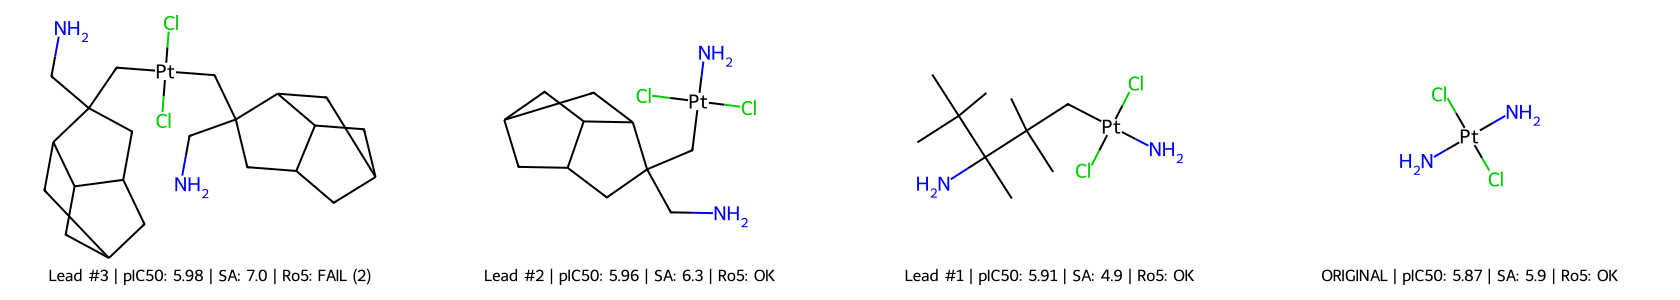

In [71]:
# ==============================================================================
# БЕЗОПАСНЫЙ СЫРОЙ (RAW) ЗАПУСК С ГАРАНТИЕЙ ЦИС-ГЕОМЕТРИИ
# ==============================================================================
my_custom_smiles = r"Cl/[Pt](Cl)(N)\N"  # Истинный Цисплатин через сырую строку Python

print("\n>>> ЗАПУСК ПОЛЬЗОВАТЕЛЬСКОЙ ОПТИМИЗАЦИИ ДЛЯ НОВОЙ МОЛЕКУЛЫ <<<")
advanced_balanced_optimization(
    designer=designer, 
    input_smiles=my_custom_smiles, 
    fragments_pool=atlas_fragments_pool, 
    max_candidates=3
)

# След шаг: протестировать алгоритм ещё на нескольких комплексах (в тч на своих) и отметить закономерности (последний шаг проекта - граммотный и честный анализ)